In [22]:
# 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# 图像处理与绘图
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 数据集划分与评估指标
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Jupyter内嵌绘图设置
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

# 自动选择设备：有显卡用显卡，没显卡用CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Current device: {device}")
print("All libraries imported successfully!")

Current device: cpu
All libraries imported successfully!


Total samples: 95
Classes: ['day', 'night']
Day samples: 50, Night samples: 45

Dataset split completed:
Train set: 66 images
Val set: 10 images
Test set: 19 images (independent)


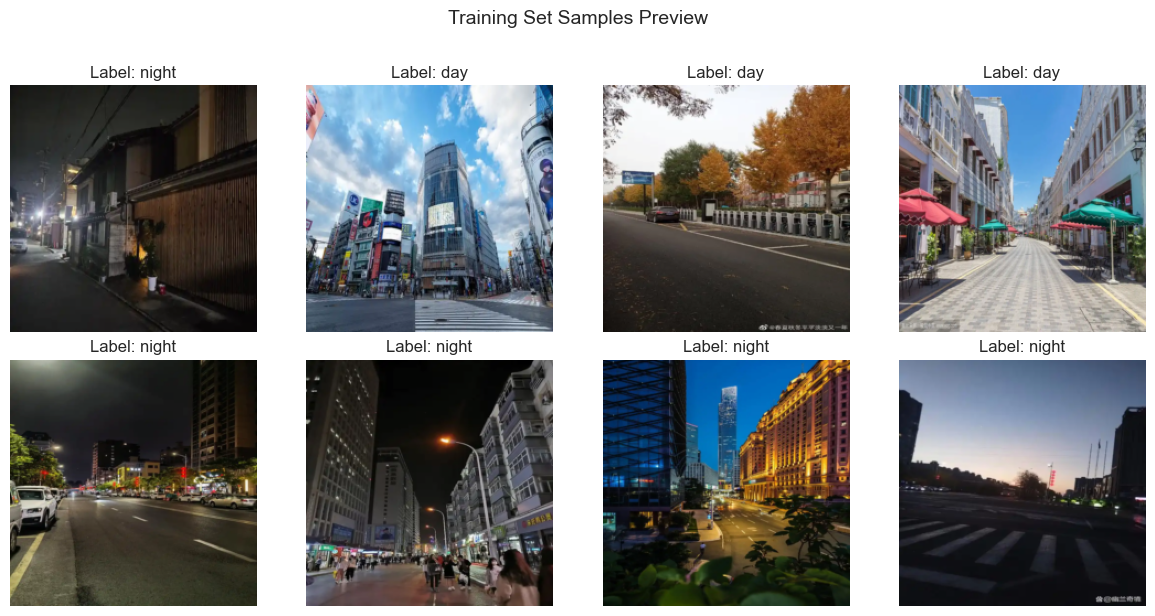

In [23]:
# ====================== 1. Image Preprocessing ======================
# Training set: light data augmentation for generalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation / test set: no augmentation, only normalization
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ====================== 2. Load Dataset (Absolute Path) ======================
dataset_path = "C:/Users/Administrator/Desktop/深度学习课程设计/dataset"
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
class_names = full_dataset.classes
all_labels = [sample[1] for sample in full_dataset.samples]

print(f"Total samples: {len(full_dataset)}")
print(f"Classes: {class_names}")
print(f"Day samples: {all_labels.count(0)}, Night samples: {all_labels.count(1)}")

# ====================== 3. Stratified Split (7:1:2) ======================
# Step 1: split 20% as independent test set (never used in training)
train_val_idx, test_idx = train_test_split(
    np.arange(len(all_labels)),
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# Step 2: split 10% of total as validation set
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.125,
    stratify=[all_labels[i] for i in train_val_idx],
    random_state=42
)

# Create subsets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

# Assign eval transform to val and test
val_dataset.dataset.transform = eval_transform
test_dataset.dataset.transform = eval_transform

# Data loaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset split completed:")
print(f"Train set: {len(train_dataset)} images")
print(f"Val set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images (independent)")

# ====================== 4. Preview Training Samples ======================
samples, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(samples): break
    img = samples[i].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Label: {class_names[sample_labels[i]]}")
    ax.axis('off')

plt.suptitle("Training Set Samples Preview", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Fix random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze backbone, only train the final classification layer
for param in model.parameters():
    param.requires_grad = False

# Replace final fc layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Model built. Using ResNet18 transfer learning, only FC layer is trainable.")

Model built. Using ResNet18 transfer learning, only FC layer is trainable.


Start training...
Epoch  1/15 | Train Loss: 0.6216  Acc: 0.7121 | Val Loss: 0.6178  Acc: 0.8000
Epoch  2/15 | Train Loss: 0.5347  Acc: 0.7273 | Val Loss: 0.5544  Acc: 0.8000
Epoch  3/15 | Train Loss: 0.5419  Acc: 0.7121 | Val Loss: 0.5099  Acc: 0.7000
Epoch  4/15 | Train Loss: 0.4084  Acc: 0.8485 | Val Loss: 0.5454  Acc: 0.8000
Epoch  5/15 | Train Loss: 0.3878  Acc: 0.8636 | Val Loss: 0.4231  Acc: 0.8000
Epoch  6/15 | Train Loss: 0.3638  Acc: 0.8485 | Val Loss: 0.4213  Acc: 0.9000
Epoch  7/15 | Train Loss: 0.3132  Acc: 0.8788 | Val Loss: 0.3853  Acc: 0.9000
Epoch  8/15 | Train Loss: 0.2424  Acc: 0.9545 | Val Loss: 0.3665  Acc: 0.8000
Epoch  9/15 | Train Loss: 0.2907  Acc: 0.8636 | Val Loss: 0.3512  Acc: 0.9000
Epoch 10/15 | Train Loss: 0.2792  Acc: 0.9091 | Val Loss: 0.3299  Acc: 0.9000
Epoch 11/15 | Train Loss: 0.2392  Acc: 0.8939 | Val Loss: 0.3106  Acc: 0.9000
Epoch 12/15 | Train Loss: 0.1896  Acc: 0.9697 | Val Loss: 0.3097  Acc: 0.8000
Epoch 13/15 | Train Loss: 0.1972  Acc: 0.9697 

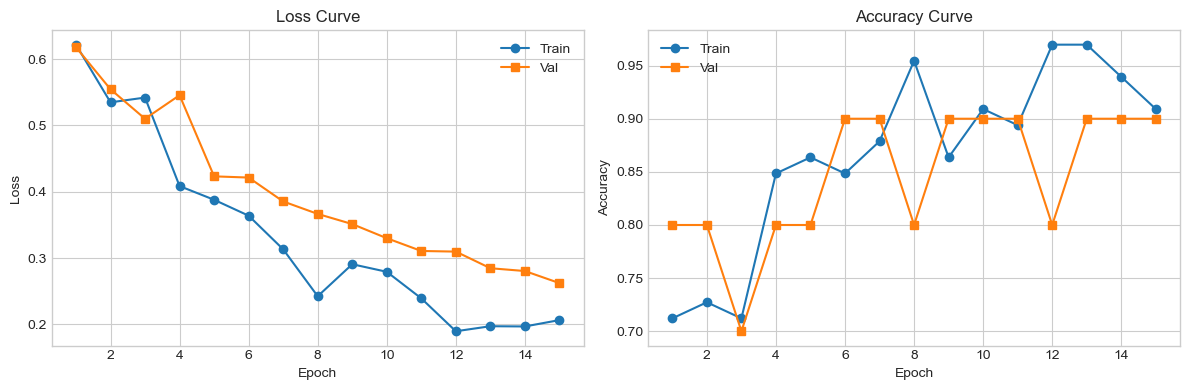

In [26]:
epochs = 15
best_val_acc = 0.0
best_model_weights = None

# Record history for plotting
train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

print("Start training...")
for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # Calculate metrics
    avg_train_loss = train_loss / train_total
    avg_train_acc = train_correct / train_total
    avg_val_loss = val_loss / val_total
    avg_val_acc = val_correct / val_total
    
    train_loss_list.append(avg_train_loss)
    train_acc_list.append(avg_train_acc)
    val_loss_list.append(avg_val_loss)
    val_acc_list.append(avg_val_acc)
    
    # Save best model by validation accuracy
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        best_model_weights = model.state_dict().copy()
    
    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f}  Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}  Acc: {avg_val_acc:.4f}")

# Load best model weights
model.load_state_dict(best_model_weights)
print(f"\nTraining finished. Best val accuracy: {best_val_acc:.4f}")

# ====================== Plot Training Curves ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs+1), train_loss_list, 'o-', label='Train')
ax1.plot(range(1, epochs+1), val_loss_list, 's-', label='Val')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(range(1, epochs+1), train_acc_list, 'o-', label='Train')
ax2.plot(range(1, epochs+1), val_acc_list, 's-', label='Val')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

【Independent Test Set Final Result】
Test set size: 19
Test accuracy: 0.9474
Confusion Matrix (rows=true, cols=pred):
[[9 1]
 [0 9]]


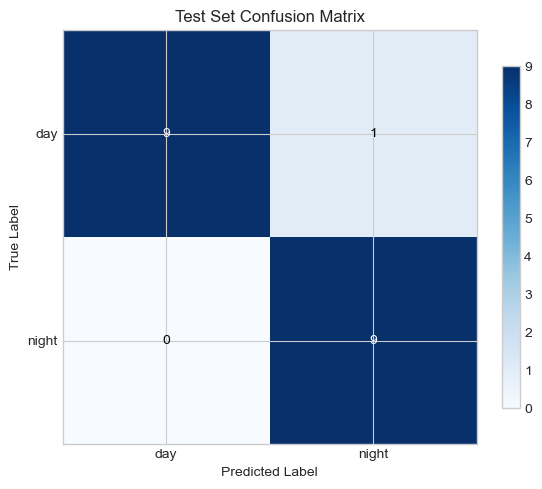

In [27]:
# Final evaluation on independent test set
model.eval()
test_preds = []
test_labels_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels_true.extend(labels.numpy())

# Calculate metrics
test_accuracy = accuracy_score(test_labels_true, test_preds)
test_cm = confusion_matrix(test_labels_true, test_preds)

print("=" * 50)
print("【Independent Test Set Final Result】")
print(f"Test set size: {len(test_labels_true)}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(test_cm)
print("=" * 50)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(test_cm, cmap=plt.cm.Blues)
plt.title("Test Set Confusion Matrix")
plt.colorbar(shrink=0.8)
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

thresh = test_cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, test_cm[i, j], ha='center', va='center',
                 color='white' if test_cm[i, j] > thresh else 'black')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [28]:
def adaptive_light_adjust(image, scene_type):
    """
    Adaptive light adjustment based on scene type.
    LAB color space for brightness adjustment to preserve color.
    Added bilateral denoising for night mode to reduce noise.
    """
    if scene_type == 'night':
        # Night mode: brighten + detail enhancement + denoising
        # 1. CLAHE on L channel
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l_enhanced = clahe.apply(l_channel)
        lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
        img_step1 = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
        
        # 2. Gamma correction for overall brightness
        gamma = 0.6
        gamma_table = np.array([((i / 255.0) ** gamma) * 255 
                               for i in np.arange(0, 256)]).astype("uint8")
        img_step2 = cv2.LUT(img_step1, gamma_table)
        
        # 3. Slight saturation boost
        img_hsv = cv2.cvtColor(img_step2, cv2.COLOR_RGB2HSV).astype(np.float32)
        img_hsv[..., 1] = np.clip(img_hsv[..., 1] * 1.3, 0, 255)
        img_step3 = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        
        # 4. Bilateral filtering (edge-preserving denoising)
        result = cv2.bilateralFilter(img_step3, d=5, sigmaColor=50, sigmaSpace=50)
        
    else:
        # Day mode: soft contrast enhancement, natural look
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
        l_enhanced = clahe.apply(l_channel)
        lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
        result = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
    
    return result

print("Optimized adaptive light adjustment function defined.")

Optimized adaptive light adjustment function defined.


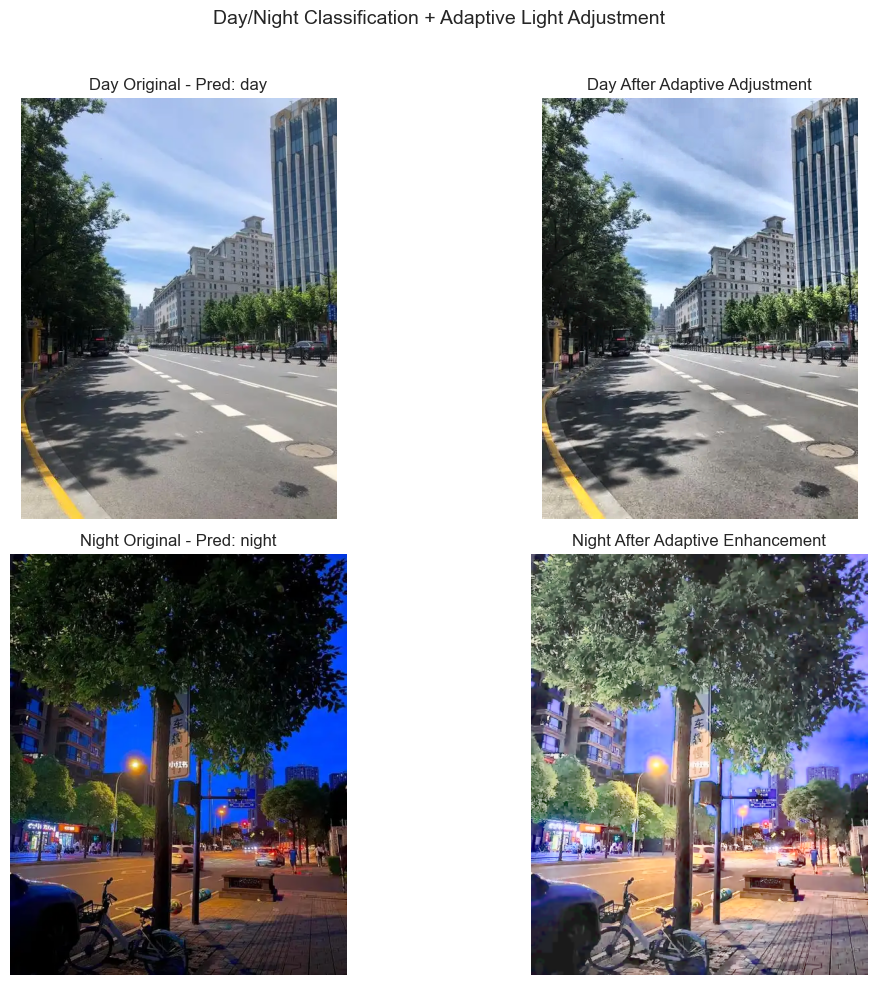

In [29]:
def predict_and_enhance(img_path):
    """End-to-end: predict scene + apply adaptive adjustment"""
    img_pil = Image.open(img_path).convert('RGB')
    img_original = np.array(img_pil)
    input_tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        _, pred_idx = torch.max(output, 1)
        pred_scene = class_names[pred_idx.item()]
    
    img_enhanced = adaptive_light_adjust(img_original, pred_scene)
    return pred_scene, img_original, img_enhanced

# ====================== Replace with your own image filenames ======================
test_day = "C:/Users/Administrator/Desktop/深度学习课程设计/dataset/day/14.png"
test_night = "C:/Users/Administrator/Desktop/深度学习课程设计/dataset/night/16.png"

# Plot comparison with fixed layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Day sample
pred_day, orig_day, enh_day = predict_and_enhance(test_day)
axes[0, 0].imshow(orig_day)
axes[0, 0].set_title(f"Day Original - Pred: {pred_day}")
axes[0, 0].axis('off')
axes[0, 1].imshow(enh_day)
axes[0, 1].set_title("Day After Adaptive Adjustment")
axes[0, 1].axis('off')

# Night sample
pred_night, orig_night, enh_night = predict_and_enhance(test_night)
axes[1, 0].imshow(orig_night)
axes[1, 0].set_title(f"Night Original - Pred: {pred_night}")
axes[1, 0].axis('off')
axes[1, 1].imshow(enh_night)
axes[1, 1].set_title("Night After Adaptive Enhancement")
axes[1, 1].axis('off')

plt.suptitle("Day/Night Classification + Adaptive Light Adjustment", y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()